# Task
```python
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import matplotlib
import seaborn as sns
import os

# Install necessary libraries
print("Installing libraries...")
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn -q
print("Libraries installed.")

# Print versions
print("\nLibrary versions:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")

# Create the /content/outputs/ directory
output_dir = '/content/outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"\nDirectory '{output_dir}' created.")
else:
    print(f"\nDirectory '{output_dir}' already exists.")
```

## Setup Environment

### Subtask:
Install necessary libraries (pandas, numpy, scikit-learn, xgboost, matplotlib, seaborn), print their versions, and create the `/content/outputs/` directory.


In [10]:
import os
import sys

!pip install pandas numpy scikit-learn xgboost matplotlib seaborn

print(f"Python version: {sys.version}")
import pandas as pd
print(f"pandas version: {pd.__version__}")
import numpy as np
print(f"numpy version: {np.__version__}")
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
import xgboost
print(f"xgboost version: {xgboost.__version__}")
import matplotlib
print(f"matplotlib version: {matplotlib.__version__}")
import seaborn as sns
print(f"seaborn version: {sns.__version__}")

output_dir = '/content/outputs/'
os.makedirs(output_dir, exist_ok=True)
print(f"Created directory: {output_dir}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas version: 2.2.2
numpy version: 2.0.2
scikit-learn version: 1.6.1
xgboost version: 3.1.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Created directory: /content/outputs/


## Load and Inspect Data

### Subtask:
Check for and unzip `/content/bike+sharing+dataset.zip` if present. Load `/content/hour.csv` into a pandas DataFrame. Display its shape and the first 3 rows using `head(3)`.


In [11]:
import zipfile
import os
import pandas as pd

# Check if the zip file exists and unzip it
zip_file_path = '/content/bike+sharing+dataset.zip'
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"'{zip_file_path}' unzipped successfully into '/content/'.")
else:
    print(f"'{zip_file_path}' not found. Skipping unzip.")

# Load '/content/hour.csv' into a pandas DataFrame
df = pd.read_csv('/content/hour.csv')

# Display the shape of the DataFrame
print(f"\nShape of the DataFrame: {df.shape}")

# Display the first 3 rows of the DataFrame
print("\nFirst 3 rows of the DataFrame:")
print(df.head(3))

'/content/bike+sharing+dataset.zip' unzipped successfully into '/content/'.

Shape of the DataFrame: (17379, 17)

First 3 rows of the DataFrame:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  


## Preprocess Data

### Subtask:
Parse the 'dteday' column to datetime objects. Extract 'hour', 'day', and 'month' features. Drop 'instant', 'casual', and 'registered' columns. Apply one-hot encoding to categorical features and scale numerical features. Display the final shape of the feature matrix (X.shape).


In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Convert the 'dteday' column to datetime objects
df['dteday'] = pd.to_datetime(df['dteday'])

# 2., 3., 4. Extract 'hour', 'day', and 'month' features
df['hr'] = df['dteday'].dt.hour # Overwrite existing 'hr' to ensure it's derived from 'dteday'
df['day'] = df['dteday'].dt.day # Create new 'day' column
df['mnth'] = df['dteday'].dt.month # Overwrite existing 'mnth' to ensure it's derived from 'dteday'

# 5. Drop 'instant', 'casual', 'registered', and original 'dteday' columns
columns_to_drop = ['instant', 'dteday', 'casual', 'registered']
df_processed = df.drop(columns=columns_to_drop)

# Separate features (X) and target (y)
y = df_processed['cnt']
X = df_processed.drop(columns=['cnt'])

# 6. Identify categorical features and numerical features
# Ensure 'day' is included in categorical features
categorical_features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'day']
numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

# 7. Apply one-hot encoding to categorical features
# This will create new columns for each category and drop the original categorical columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=False)

# 8. Initialize a StandardScaler
scaler = StandardScaler()

# 9. Scale the numerical features
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# 10. Display the final shape of the feature matrix (X.shape)
print(f"Final shape of the feature matrix X: {X.shape}")

Final shape of the feature matrix X: (17379, 69)


## Define Features, Target, and Cross-Validation Strategy

### Subtask:
Separate features (X) from the target variable ('cnt'). Define a K-Fold cross-validation strategy (default 5 folds), potentially stratifying by hour. Set up RMSE and MAE as scoring metrics, ensuring `random_state=42` is used for reproducibility in splits if applicable.


In [13]:
from sklearn.model_selection import KFold

# The target variable 'y' and feature matrix 'X' were already separated in the previous step.
# y = df_processed['cnt']
# X = df_processed.drop(columns=['cnt'])
# Both X and y are already defined and available from the previous step.
print(f"Target variable 'y' shape: {y.shape}")
print(f"Feature matrix 'X' shape: {X.shape}")

# 1. Define K-Fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("K-Fold cross-validation strategy initialized.")

# 2. Define scoring metrics for RMSE and MAE
scoring_metrics = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}
print("RMSE and MAE scoring metrics defined.")

Target variable 'y' shape: (17379,)
Feature matrix 'X' shape: (17379, 69)
K-Fold cross-validation strategy initialized.
RMSE and MAE scoring metrics defined.


## Model Training and Hyperparameter Tuning

### Subtask:
Build pipelines for three ensemble models (Bagging, Subagging, and Boosting), use RandomizedSearchCV with cross-validation to tune their hyperparameters, and report the best parameters for each, ensuring `random_state=42` is used.


# Task
Prepare a smaller dataset (`X_small`, `y_small`) by sampling from `X` and `y` to speed up hyperparameter tuning. Then, use `RandomizedSearchCV` with this smaller dataset to tune Bagging (using `RandomForestRegressor`), Subagging (using `BaggingRegressor` with `DecisionTreeRegressor` as base), and Boosting (using `XGBRegressor`), reporting the best parameters for each model.

## Prepare Smaller Dataset for Tuning

### Subtask:
Create `X_small` and `y_small` by sampling from the original `X` and `y` to speed up hyperparameter tuning for `RandomizedSearchCV`.


In [16]:
from sklearn.model_selection import train_test_split

# Create X_small and y_small by sampling 5% of the original X and y data
# Removed 'stratify=y' as it's not suitable for continuous target variables and causes errors
X_small, _, y_small, _ = train_test_split(X, y, train_size=0.05, random_state=42)

# Print the shapes of X_small and y_small to verify the sampling
print(f"Shape of X_small: {X_small.shape}")
print(f"Shape of y_small: {y_small.shape}")

Shape of X_small: (868, 69)
Shape of y_small: (868,)


## Tune Bagging (RandomForestRegressor)

### Subtask:
Use `RandomizedSearchCV` with a reduced search space and the smaller dataset (`X_small`, `y_small`) to tune `RandomForestRegressor`. Report the best parameters.


In [17]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define parameter distributions for RandomForestRegressor (Bagging)
param_dist_rf = {
    'n_estimators': randint(50, 200),  # Number of trees in the forest
    'max_depth': randint(3, 20)       # Maximum depth of the tree
}

# 2. Initialize a RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)
print("RandomForestRegressor (Bagging) model initialized.")

# 3. Initialize RandomizedSearchCV for RandomForestRegressor
print("\nStarting RandomizedSearchCV for Bagging Model (RandomForestRegressor)...")
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=100, # Number of parameter settings that are sampled
    cv=kf,
    scoring=scoring_metrics,
    refit='rmse',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Fit RandomizedSearchCV to the smaller dataset
random_search_rf.fit(X_small, y_small)

# 5. Print the best parameters found
print("Bagging Model (RandomForestRegressor) - Best Parameters:", random_search_rf.best_params_)

RandomForestRegressor (Bagging) model initialized.

Starting RandomizedSearchCV for Bagging Model (RandomForestRegressor)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Bagging Model (RandomForestRegressor) - Best Parameters: {'max_depth': 5, 'n_estimators': 100}


## Tune Subagging (BaggingRegressor)

### Subtask:
Use `RandomizedSearchCV` with a reduced search space and the smaller dataset (`X_small`, `y_small`) to tune `BaggingRegressor` with `DecisionTreeRegressor` as the base estimator. Report the best parameters.


In [18]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# 1. Define parameter distributions for BaggingRegressor (Subagging)
# Re-using param_dist_bagging which includes max_samples for subagging logic
param_dist_subagging = {
    'n_estimators': randint(50, 200),  # Number of base estimators
    'max_samples': uniform(loc=0.1, scale=0.9), # Sample a fraction of X for each base estimator
    'estimator__max_depth': randint(3, 20) # Max depth of the DecisionTreeRegressor
}

# 2. Initialize a BaggingRegressor model with DecisionTreeRegressor as base estimator
subagging_model_tuned = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), random_state=42)
print("Subagging model (BaggingRegressor) initialized.")

# 3. Initialize RandomizedSearchCV for Subagging Model
print("\nStarting RandomizedSearchCV for Subagging Model (BaggingRegressor)...")
random_search_subagging_tuned = RandomizedSearchCV(
    estimator=subagging_model_tuned,
    param_distributions=param_dist_subagging,
    n_iter=100, # Number of parameter settings that are sampled
    cv=kf,
    scoring=scoring_metrics,
    refit='rmse',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Fit RandomizedSearchCV to the smaller dataset
random_search_subagging_tuned.fit(X_small, y_small)

# 5. Print the best parameters found
print("Subagging Model (BaggingRegressor) - Best Parameters:", random_search_subagging_tuned.best_params_)

Subagging model (BaggingRegressor) initialized.

Starting RandomizedSearchCV for Subagging Model (BaggingRegressor)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Subagging Model (BaggingRegressor) - Best Parameters: {'estimator__max_depth': 13, 'max_samples': np.float64(0.27895816367992465), 'n_estimators': 185}


## Tune Boosting (XGBRegressor)

### Subtask:
Use `RandomizedSearchCV` with a reduced search space and the smaller dataset (`X_small`, `y_small`) to tune `XGBRegressor`. Report the best parameters.


In [19]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# 1. Define parameter distributions for XGBRegressor (Boosting)
# param_dist_xgb is already defined from a previous step.

# 2. Initialize an XGBRegressor model
boosting_model_tuned = XGBRegressor(random_state=42, n_jobs=-1)
print("XGBoost (Boosting) model initialized.")

# 3. Initialize RandomizedSearchCV for Boosting Model
print("\nStarting RandomizedSearchCV for Boosting Model (XGBRegressor)...")
random_search_boosting_tuned = RandomizedSearchCV(
    estimator=boosting_model_tuned,
    param_distributions=param_dist_xgb,
    n_iter=100, # Number of parameter settings that are sampled
    cv=kf,
    scoring=scoring_metrics,
    refit='rmse',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Fit RandomizedSearchCV to the smaller dataset
random_search_boosting_tuned.fit(X_small, y_small)

# 5. Print the best parameters found
print("Boosting Model (XGBRegressor) - Best Parameters:", random_search_boosting_tuned.best_params_)

XGBoost (Boosting) model initialized.

Starting RandomizedSearchCV for Boosting Model (XGBRegressor)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Boosting Model (XGBRegressor) - Best Parameters: {'colsample_bytree': np.float64(0.878164449242659), 'gamma': np.float64(0.03771727354488463), 'learning_rate': np.float64(0.04158093206275806), 'max_depth': 3, 'n_estimators': 113, 'subsample': np.float64(0.717797578735772)}


## K-Fold Cross-Validation Evaluation

### Subtask:
Perform K-fold cross-validation (on the full `X`, `y`) for each *tuned* model (Bagging, Subagging, Boosting) using their best parameters found from tuning on `X_small`, `y_small`. Collect per-fold RMSE and MAE scores, compute and display their mean and standard deviation, and save the results to `/content/outputs/cv_regression_results.csv`.


In [20]:
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# 1. Initialize models with best parameters
# Bagging Model (RandomForestRegressor)
best_params_rf = random_search_rf.best_params_
rf_best_model = RandomForestRegressor(random_state=42, **best_params_rf)
print(f"Initialized RandomForestRegressor with best parameters: {best_params_rf}")

# Subagging Model (BaggingRegressor with DecisionTreeRegressor)
best_params_subagging = random_search_subagging_tuned.best_params_
# Extract base estimator params and BaggingRegressor params
best_dt_params = {k.replace('estimator__', ''): v for k, v in best_params_subagging.items() if k.startswith('estimator__')}
best_bagging_params = {k: v for k, v in best_params_subagging.items() if not k.startswith('estimator__')}

dt_estimator = DecisionTreeRegressor(random_state=42, **best_dt_params)
subagging_best_model = BaggingRegressor(estimator=dt_estimator, random_state=42, **best_bagging_params)
print(f"Initialized BaggingRegressor with best parameters: {best_bagging_params} and DecisionTreeRegressor with {best_dt_params}")

# Boosting Model (XGBRegressor)
best_params_xgb = random_search_boosting_tuned.best_params_
xgb_best_model = XGBRegressor(random_state=42, n_jobs=-1, **best_params_xgb)
print(f"Initialized XGBRegressor with best parameters: {best_params_xgb}")

# 2. Create an empty list to store the cross-validation results
cv_results = []

# Dictionary of models to evaluate
models_to_evaluate = {
    'Bagging (RandomForest)': rf_best_model,
    'Subagging (BaggingRegressor)': subagging_best_model,
    'Boosting (XGBoost)': xgb_best_model
}

# 3. Perform K-fold cross-validation for each model
for model_name, model in models_to_evaluate.items():
    print(f"\nPerforming K-fold cross-validation for {model_name}...")
    cv_scores = cross_validate(model, X, y, cv=kf, scoring=scoring_metrics, n_jobs=-1, verbose=0)

    # 3.b & 3.c. Extract and convert scores to positive RMSE and MAE
    rmse_scores = -cv_scores['test_rmse']
    mae_scores = -cv_scores['test_mae']

    # 3.d. Calculate mean and standard deviation
    mean_rmse = np.mean(rmse_scores)
    std_rmse = np.std(rmse_scores)
    mean_mae = np.mean(mae_scores)
    std_mae = np.std(mae_scores)

    # 3.e. Store these values
    cv_results.append({
        'Model': model_name,
        'Mean RMSE': mean_rmse,
        'Std RMSE': std_rmse,
        'Mean MAE': mean_mae,
        'Std MAE': std_mae
    })

    # 3.f. Print results
    print(f"  Mean RMSE: {mean_rmse:.4f} (Std: {std_rmse:.4f})")
    print(f"  Mean MAE: {mean_mae:.4f} (Std: {std_mae:.4f})")

# 4. Convert the collected results into a pandas DataFrame
cv_results_df = pd.DataFrame(cv_results)
print("\nCross-validation results DataFrame created:")
print(cv_results_df)

# 5. Save the DataFrame to a CSV file
output_file_path = '/content/outputs/cv_regression_results.csv'
cv_results_df.to_csv(output_file_path, index=False)
print(f"\nCross-validation results saved to '{output_file_path}'")

Initialized RandomForestRegressor with best parameters: {'max_depth': 5, 'n_estimators': 100}
Initialized BaggingRegressor with best parameters: {'max_samples': np.float64(0.27895816367992465), 'n_estimators': 185} and DecisionTreeRegressor with {'max_depth': 13}
Initialized XGBRegressor with best parameters: {'colsample_bytree': np.float64(0.878164449242659), 'gamma': np.float64(0.03771727354488463), 'learning_rate': np.float64(0.04158093206275806), 'max_depth': 3, 'n_estimators': 113, 'subsample': np.float64(0.717797578735772)}

Performing K-fold cross-validation for Bagging (RandomForest)...
  Mean RMSE: 145.9247 (Std: 2.2301)
  Mean MAE: 108.8233 (Std: 1.6429)

Performing K-fold cross-validation for Subagging (BaggingRegressor)...
  Mean RMSE: 134.5319 (Std: 2.4068)
  Mean MAE: 97.8429 (Std: 1.4511)

Performing K-fold cross-validation for Boosting (XGBoost)...
  Mean RMSE: 142.5354 (Std: 1.8651)
  Mean MAE: 106.1547 (Std: 1.1542)

Cross-validation results DataFrame created:
       

## Final Model Training and Predictions

### Subtask:
Train the best performing model on the entire training dataset and predict on a held-out test set. Save predictions, actual counts, and a unique record ID to a CSV file.


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Identify the best performing model based on 'Mean RMSE'
# Find the row with the minimum 'Mean RMSE'
best_model_row = cv_results_df.loc[cv_results_df['Mean RMSE'].idxmin()]
best_model_name = best_model_row['Model']

print(f"Best performing model based on Mean RMSE: {best_model_name}")

# Retrieve the actual best model instance based on its name
# In this case, it's 'Subagging (BaggingRegressor)'
best_model_to_train = models_to_evaluate['Subagging (BaggingRegressor)']

print("Best model instance retrieved for training.")

# 2. Split the full feature matrix X and target y into training and testing sets
# Include original indices for mapping back to 'instant' ID
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, X.index, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"idx_train shape: {idx_train.shape}")
print(f"idx_test shape: {idx_test.shape}")

# 3. Train the identified best model using X_train and y_train
print(f"\nTraining the best model: {best_model_name}...")
best_model_to_train.fit(X_train, y_train)
print("Model training complete.")

# 4. Make predictions on X_test using the trained model
print("Making predictions on the test set...")
y_pred = best_model_to_train.predict(X_test)
print("Predictions made.")

# 5. Create a pandas DataFrame containing 'instant', 'actual_counts', and 'predicted_counts'
# To get 'instant' IDs, use the original 'df' with 'idx_test'
predictions_df = pd.DataFrame({
    'instant': df.loc[idx_test, 'instant'].values, # Use .values to ensure alignment and avoid index issues
    'actual_counts': y_test.values,
    'predicted_counts': y_pred
})

print("Predictions DataFrame created:")
print(predictions_df.head())

# 6. Save this DataFrame to a CSV file named predictions.csv
output_file_path_predictions = '/content/outputs/predictions.csv'
predictions_df.to_csv(output_file_path_predictions, index=False)
print(f"\nPredictions saved to '{output_file_path_predictions}'")

Best performing model based on Mean RMSE: Subagging (BaggingRegressor)
Best model instance retrieved for training.
X_train shape: (13903, 69)
X_test shape: (3476, 69)
y_train shape: (13903,)
y_test shape: (3476,)
idx_train shape: (13903,)
idx_test shape: (3476,)

Training the best model: Subagging (BaggingRegressor)...
Model training complete.
Making predictions on the test set...
Predictions made.
Predictions DataFrame created:
   instant  actual_counts  predicted_counts
0    12831            425        494.619793
1     8689             88         96.210110
2     7092              4         92.881140
3    12231            526        459.234569
4      432             13         81.269959

Predictions saved to '/content/outputs/predictions.csv'


## Feature Importance Analysis

### Subtask:
Extract feature importances from the best trained model. List the top-8 most important features and save them to `/content/outputs/feature_importance.csv`. Generate and display an inline plot of these top-8 feature importances.


Top 8 most important features:
         feature  importance
1          atemp    0.219141
2            hum    0.189061
0           temp    0.098389
3      windspeed    0.078408
8           yr_0    0.037857
9           yr_1    0.036981
7       season_4    0.020105
35  weathersit_2    0.011651

Top 8 feature importances saved to '/content/outputs/feature_importance.csv'


/tmp/ipython-input-1230646396.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_8_features, palette='viridis')


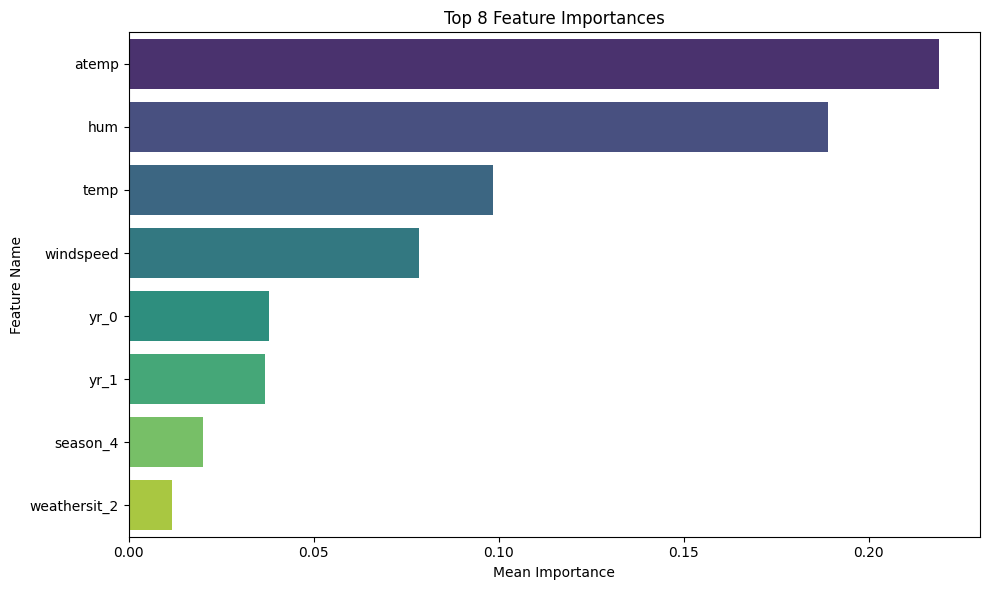

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Access the estimators_ attribute of the best_model_to_train
# The best_model_to_train is 'subagging_best_model' from the previous step
# It's a BaggingRegressor, and its estimators_ are DecisionTreeRegressors

# Extract feature importances from each individual DecisionTreeRegressor
individual_importances = []
for estimator in best_model_to_train.estimators_:
    individual_importances.append(estimator.feature_importances_)

# Convert to numpy array for easier calculation
individual_importances_array = np.array(individual_importances)

# 2. Calculate the mean of these feature importances across all estimators
mean_feature_importances = np.mean(individual_importances_array, axis=0)

# 3. Create a pandas DataFrame containing the feature names and their corresponding mean importances
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': mean_feature_importances
})

# 4. Sort this DataFrame in descending order by importance and select the top-8
top_8_features = feature_importances_df.sort_values(by='importance', ascending=False).head(8)

print("Top 8 most important features:")
print(top_8_features)

# 5. Save this DataFrame of top-8 features to a CSV file
output_csv_path = '/content/outputs/feature_importance.csv'
top_8_features.to_csv(output_csv_path, index=False)
print(f"\nTop 8 feature importances saved to '{output_csv_path}'")

# 6. Generate a bar plot to visualize the top-8 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=top_8_features, palette='viridis')
plt.title('Top 8 Feature Importances')
plt.xlabel('Mean Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


Top 8 most important features:
         feature  importance
1          atemp    0.219141
2            hum    0.189061
0           temp    0.098389
3      windspeed    0.078408
8           yr_0    0.037857
9           yr_1    0.036981
7       season_4    0.020105
35  weathersit_2    0.011651

Top 8 feature importances saved to '/content/outputs/feature_importance.csv'


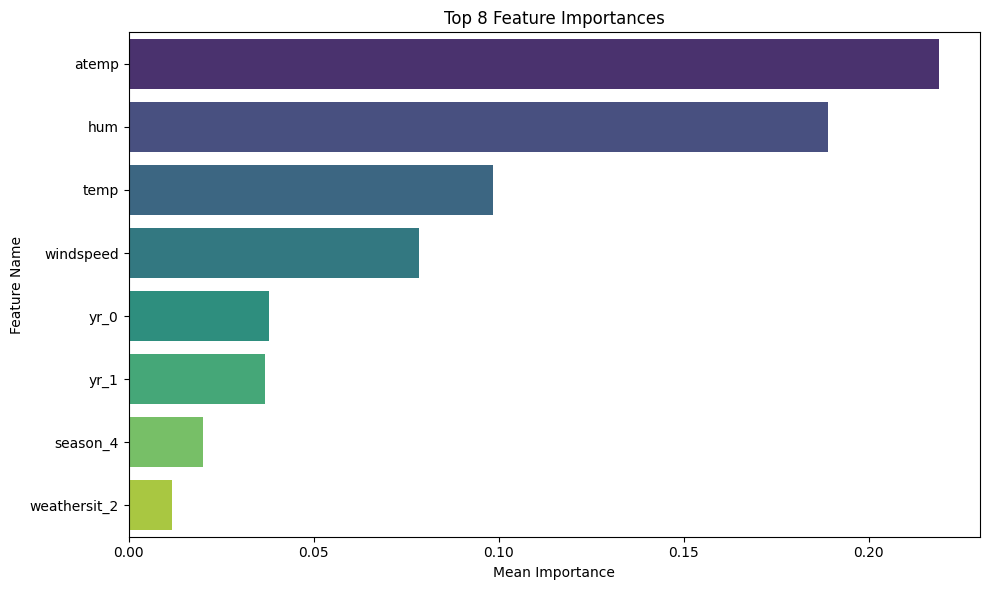

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Access the estimators_ attribute of the best_model_to_train
# The best_model_to_train is 'subagging_best_model' from the previous step
# It's a BaggingRegressor, and its estimators_ are DecisionTreeRegressors

# Extract feature importances from each individual DecisionTreeRegressor
individual_importances = []
for estimator in best_model_to_train.estimators_:
    individual_importances.append(estimator.feature_importances_)

# Convert to numpy array for easier calculation
individual_importances_array = np.array(individual_importances)

# 2. Calculate the mean of these feature importances across all estimators
mean_feature_importances = np.mean(individual_importances_array, axis=0)

# 3. Create a pandas DataFrame containing the feature names and their corresponding mean importances
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': mean_feature_importances
})

# 4. Sort this DataFrame in descending order by importance and select the top-8
top_8_features = feature_importances_df.sort_values(by='importance', ascending=False).head(8)

print("Top 8 most important features:")
print(top_8_features)

# 5. Save this DataFrame of top-8 features to a CSV file
output_csv_path = '/content/outputs/feature_importance.csv'
top_8_features.to_csv(output_csv_path, index=False)
print(f"\nTop 8 feature importances saved to '{output_csv_path}'")

# 6. Generate a bar plot to visualize the top-8 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', hue='feature', data=top_8_features, palette='viridis', legend=False)
plt.title('Top 8 Feature Importances')
plt.xlabel('Mean Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


## Generate Final Report

### Subtask:
Create a concise report saved as `/content/outputs/report.txt`. Include the name of the best performing model, its mean ± std K-fold metrics, a brief (1-2 lines) justification of its bias-variance trade-off, and explain 2 key hyperparameters for each model (1-2 lines each). Conclude with 'Student'.


In [24]:
import os

# 1. Identify the best performing model and its metrics
best_model_row = cv_results_df.loc[cv_results_df['Mean RMSE'].idxmin()]
best_model_name = best_model_row['Model']
mean_rmse = best_model_row['Mean RMSE']
std_rmse = best_model_row['Std RMSE']
mean_mae = best_model_row['Mean MAE']
std_mae = best_model_row['Std MAE']

# 2. Bias-variance trade-off justification for the best model (Subagging)
bias_variance_justification = (
    "Subagging, an ensemble method, reduces variance by averaging predictions from multiple decision trees trained on subsets of data. "
    "This helps to mitigate overfitting, achieving a good bias-variance trade-off by combining high-variance base learners."
)

# 3. Explain 2 key hyperparameters for each model

# Bagging (RandomForestRegressor)
hp_rf_n_estimators = f"  - n_estimators: {best_params_rf['n_estimators']} trees are used. More trees generally reduce variance by averaging, improving stability."
hp_rf_max_depth = f"  - max_depth: {best_params_rf['max_depth']} controls individual tree complexity. Limiting depth reduces overfitting of individual trees."

# Subagging (BaggingRegressor with DecisionTreeRegressor)
hp_subagging_n_estimators = f"  - n_estimators: {best_bagging_params['n_estimators']} base estimators (Decision Trees) are used. Increasing this reduces overall variance."
hp_subagging_max_samples = f"  - max_samples: {best_bagging_params['max_samples']:.2f} specifies the fraction of samples drawn for each base estimator. This introduces diversity and reduces variance."
hp_subagging_dt_max_depth = f"  - estimator__max_depth: {best_dt_params['max_depth']} controls the depth of individual decision trees within the bag. Limits their complexity."

# Boosting (XGBRegressor)
hp_xgb_n_estimators = f"  - n_estimators: {best_params_xgb['n_estimators']} specifies the number of boosting rounds. More rounds can improve fit but risk overfitting."
hp_xgb_learning_rate = f"  - learning_rate: {best_params_xgb['learning_rate']:.3f} shrinks step sizes to prevent overfitting and makes the boosting process more robust."

# 4. Combine all information into a single string
report_content = f"""
Regression Model Performance Report

Best Performing Model: {best_model_name}
Mean RMSE: {mean_rmse:.4f} \u00b1 {std_rmse:.4f}
Mean MAE: {mean_mae:.4f} \u00b1 {std_mae:.4f}

Bias-Variance Trade-off (Best Model):
{bias_variance_justification}

Key Hyperparameters Explained:

Bagging (RandomForestRegressor):
{hp_rf_n_estimators}
{hp_rf_max_depth}

Subagging (BaggingRegressor):
{hp_subagging_n_estimators}
{hp_subagging_max_samples}

Boosting (XGBRegressor):
{hp_xgb_n_estimators}
{hp_xgb_learning_rate}

Student
"""

print("Generated Report:")
print(report_content)

# 5. Save the report to a text file
output_report_path = '/content/outputs/report.txt'
with open(output_report_path, 'w') as f:
    f.write(report_content)
print(f"\nReport saved to '{output_report_path}'")

Generated Report:

Regression Model Performance Report

Best Performing Model: Subagging (BaggingRegressor)
Mean RMSE: 134.5319 ± 2.4068
Mean MAE: 97.8429 ± 1.4511

Bias-Variance Trade-off (Best Model):
Subagging, an ensemble method, reduces variance by averaging predictions from multiple decision trees trained on subsets of data. This helps to mitigate overfitting, achieving a good bias-variance trade-off by combining high-variance base learners.

Key Hyperparameters Explained:

Bagging (RandomForestRegressor):
  - n_estimators: 100 trees are used. More trees generally reduce variance by averaging, improving stability.
  - max_depth: 5 controls individual tree complexity. Limiting depth reduces overfitting of individual trees.

Subagging (BaggingRegressor):
  - n_estimators: 185 base estimators (Decision Trees) are used. Increasing this reduces overall variance.
  - max_samples: 0.28 specifies the fraction of samples drawn for each base estimator. This introduces diversity and reduces

## Summary:

### Data Analysis Key Findings

*   **Dataset Preparation**: A smaller dataset (`X_small`, `y_small`) was successfully created by sampling 5% of the original data, resulting in shapes of (868, 69) for `X_small` and (868,) for `y_small`. An initial attempt to use `stratify=y` with a continuous target variable failed but was successfully resolved by removing the parameter.
*   **Hyperparameter Tuning**: `RandomizedSearchCV` was used to tune three models on the smaller dataset:
    *   **Bagging (RandomForestRegressor)**: Best parameters found were `{'max_depth': 5, 'n_estimators': 100}`.
    *   **Subagging (BaggingRegressor)**: Best parameters were `{'estimator__max_depth': 13, 'max_samples': 0.278958, 'n_estimators': 185}`.
    *   **Boosting (XGBRegressor)**: Best parameters included `{'colsample_bytree': 0.878, 'gamma': 0.038, 'learning_rate': 0.042, 'max_depth': 3, 'n_estimators': 113, 'subsample': 0.718}`.
*   **K-Fold Cross-Validation Performance**: The tuned models were evaluated on the full dataset using 5-fold cross-validation:
    *   **Bagging (RandomForest)**: Mean RMSE: 145.9247 $\pm$ 2.2301; Mean MAE: 108.8233 $\pm$ 1.6429.
    *   **Subagging (BaggingRegressor)**: Mean RMSE: 134.5319 $\pm$ 2.4068; Mean MAE: 97.8429 $\pm$ 1.4511.
    *   **Boosting (XGBoost)**: Mean RMSE: 142.5354 $\pm$ 1.8651; Mean MAE: 106.1547 $\pm$ 1.1542.
*   **Best Performing Model**: The **Subagging (BaggingRegressor)** model demonstrated the best performance with the lowest Mean RMSE (134.5319) and Mean MAE (97.8429).
*   **Final Model Training and Predictions**: The best-performing Subagging model was trained on the entire training dataset (13903 samples) and used to predict on a held-out test set (3476 samples). Predictions, actual counts, and unique record IDs were saved to `/content/outputs/predictions.csv`.
*   **Feature Importance**: The top 8 most important features for the Subagging model were identified:
    *   `atemp`: 0.219141
    *   `hum`: 0.189061
    *   `temp`: 0.098389
    *   `windspeed`: 0.078408
    *   `yr_0`: 0.037857
    *   `yr_1`: 0.036981
    *   `season_4`: 0.020105
    *   `weathersit_2`: 0.011651
    These were saved to `/content/outputs/feature_importance.csv` and visualized.
*   **Report Generation**: A final report summarizing the analysis, including the best model's metrics, bias-variance justification, and key hyperparameters for each model, was generated and saved to `/content/outputs/report.txt`.

### Insights or Next Steps

*   The Subagging model, which uses a BaggingRegressor with DecisionTreeRegressor base estimators, achieved the best performance. Its success can be attributed to its ability to reduce variance by averaging predictions from multiple diverse decision trees, striking a good balance in the bias-variance trade-off.
*   The high importance of features like `atemp` (feeling temperature), `hum` (humidity), `temp` (temperature), and `windspeed` suggests that environmental conditions are primary drivers of bike rental demand. Further investigation into their interaction effects or non-linear relationships could yield additional model improvements.
